# Chapter 12: Pharmaceutical Data Visualization with Matplotlib

**B.Pharm companion Jupyter notebook — worked examples and concept demonstrations**

## Chapter focus

Choose suitable plots, label variables and units, compare distributions and time profiles, calculate cautious descriptive summaries and export figures.

## Pharmacy context

All plots use simulated data. ADR reporting summaries are not incidence or risk estimates; sampled PK summaries are not dosing recommendations; dissolution means and SD bars do not establish pharmacopoeial compliance.

## Important notes and how to use this notebook

1. Use a Python 3 kernel. Read the problem and algorithm, predict the result, then run the cell with **Shift+Enter**.
2. Choose **Restart Kernel and Run All Cells** to reproduce the saved outputs. Run from top to bottom; later demonstrations may use earlier variables.
3. Outputs below code cells were produced by execution. Paths, versions, memory diagnostics and set display order can differ between computers.
4. All records are simulated for education. Retain units and distinguish a descriptive result from a clinical or regulatory decision.
5. Files written by examples are kept in `outputs/chapter_12`. Rerunning a file-writing example replaces its own generated output.

**Packages:** `numpy`, `pandas`, `matplotlib`. If required, run this once in a separate cell and restart the kernel:

```python
%pip install numpy pandas matplotlib
```

Use NumPy 2.0 or later (`np.trapezoid`) and Matplotlib 3.9 or later (`tick_labels`).

**Data files:** `adr_reporting.csv`, `dissolution.csv`, `pk_oral_iv.csv`, `tablet_qc.csv`.

Extract the Chapter 12 dataset ZIP beside this notebook, preserving `data/chapter_12`. Individual data files can also be placed in the same folder as the notebook. The setup cell searches both locations.


In [1]:
from pathlib import Path

WORKSHOP_ROOT = Path.cwd().resolve()
OUTPUT_DIR = WORKSHOP_ROOT / "outputs" / "chapter_12"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_files = ['adr_reporting.csv', 'dissolution.csv', 'pk_oral_iv.csv', 'tablet_qc.csv']
candidates = [WORKSHOP_ROOT / "data" / "chapter_12", WORKSHOP_ROOT]
DATA_DIR = next((folder for folder in candidates
                 if all((folder / name).is_file() for name in required_files)), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Extract the chapter dataset ZIP beside this notebook or put all listed data files in the notebook folder."
    )
print("Companion data files found:", len(required_files))

print("Chapter 12 ready. Generated files: outputs/chapter_12")

Companion data files found: 4
Chapter 12 ready. Generated files: outputs/chapter_12


## Contents

- [01. 12.3.1 Companion Synthetic Datasets](#example-12-1)
- [02. 12.4 Installing Matplotlib and Preparing Jupyter Notebook](#example-12-2)
- [03. 12.4 Installing Matplotlib and Preparing Jupyter Notebook](#example-12-3)
- [04. Worked Program 12.1 - Creating a Figure and Axes](#example-12-4)
- [05. Worked Program 12.2 - Line Plot of a Dissolution Trend](#example-12-5)
- [06. Worked Program 12.3 - Histogram of Tablet Weights](#example-12-6)
- [07. Worked Program 12.4 - Tablet Hardness versus Disintegration Time](#example-12-7)
- [08. Worked Program 12.5 - Comparing Assay Results by Batch](#example-12-8)
- [09. Worked Program 12.6 - Adding Labels, Legend and Grid to Two Curves](#example-12-9)
- [10. Worked Program 12.7 - Two Axes in One Figure and Exporting the Figure](#example-12-10)
- [11. Worked Program 12.8 - Oral and IV Profiles with Cmax, Tmax and Sampled AUC](#example-12-11)
- [12. 12.16 Scientific PK Interpretation: Terminal Slope, Half-life and Relative Bioavailability](#example-12-12)
- [13. Worked Program 12.9 - Bar Chart of Simulated ADR Reporting Rates](#example-12-13)
- [14. Worked Program 12.10 - Comparing Three Dissolution Profiles with SD Error Bars](#example-12-14)
- [15. Worked Program 12.11 - Creating and Saving an ADR Summary Figure](#example-12-15)

<a id="example-12-1"></a>

## 01. 12.3.1 Companion Synthetic Datasets

### Problem statement

Demonstrate companion Synthetic Datasets using the simulated values or objects in the cell below.

### Objective

Understand how the Python operations in this example support companion synthetic datasets and interpret the result correctly.

### Pharmacy context

All plots use simulated data. ADR reporting summaries are not incidence or risk estimates; sampled PK summaries are not dosing recommendations; dissolution means and SD bars do not establish pharmacopoeial compliance.

### Algorithm

1. Import `pathlib`.
2. Store `['tablet_qc.csv', 'pk_oral_iv.csv', 'adr_reporting.csv', 'dissolution.csv']` in `required_files`.
3. Repeat the indented steps for `file_name` in `required_files`.

### Code and executed output

The output appears directly below the code cell.

In [2]:
from pathlib import Path

required_files = [
    "tablet_qc.csv",
    "pk_oral_iv.csv",
    "adr_reporting.csv",
    "dissolution.csv",
]

for file_name in required_files:
    status = "FOUND" if (DATA_DIR / file_name).exists() else "NOT FOUND"
    print(f"{file_name}: {status}")

tablet_qc.csv: FOUND
pk_oral_iv.csv: FOUND
adr_reporting.csv: FOUND
dissolution.csv: FOUND


### Explanation

Place the four companion files in the same folder as the Jupyter Notebook. Run the following pre-check before the file-based worked programs. If a file is reported as NOT FOUND, correct the working folder or file name before continuing.

### Interpretation

All plots use simulated data. ADR reporting summaries are not incidence or risk estimates; sampled PK summaries are not dosing recommendations; dissolution means and SD bars do not establish pharmacopoeial compliance.

<a id="example-12-2"></a>

## 02. 12.4 Installing Matplotlib and Preparing Jupyter Notebook

### Problem statement

Demonstrate installing Matplotlib and Preparing Jupyter Notebook using the simulated values or objects in the cell below.

### Objective

Understand how the Python operations in this example support installing matplotlib and preparing jupyter notebook and interpret the result correctly.

### Pharmacy context

All plots use simulated data. ADR reporting summaries are not incidence or risk estimates; sampled PK summaries are not dosing recommendations; dissolution means and SD bars do not establish pharmacopoeial compliance.

### Algorithm

1. Import `matplotlib`.
2. Import `matplotlib.pyplot`.
3. Import `numpy`.
4. Import `pandas`.
5. Display the results for inspection.

### Code and executed output

The output appears directly below the code cell.

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Matplotlib version:", matplotlib.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Matplotlib version: 3.10.8
NumPy version: 2.3.5
Pandas version: 2.2.3


### Explanation

`matplotlib.pyplot` is conventionally imported as `plt`. NumPy and Pandas are included because Matplotlib can plot arrays and DataFrame columns directly. If `ModuleNotFoundError` appears, run `%pip install matplotlib` in the same notebook kernel and restart the kernel if required. Anaconda installations commonly include Matplotlib already.

### Interpretation

All plots use simulated data. ADR reporting summaries are not incidence or risk estimates; sampled PK summaries are not dosing recommendations; dissolution means and SD bars do not establish pharmacopoeial compliance.

<a id="example-12-3"></a>

## 03. 12.4 Installing Matplotlib and Preparing Jupyter Notebook

### Problem statement

Demonstrate installing Matplotlib and Preparing Jupyter Notebook using the simulated values or objects in the cell below.

### Objective

Understand how the Python operations in this example support installing matplotlib and preparing jupyter notebook and interpret the result correctly.

### Pharmacy context

All plots use simulated data. ADR reporting summaries are not incidence or risk estimates; sampled PK summaries are not dosing recommendations; dissolution means and SD bars do not establish pharmacopoeial compliance.

### Algorithm

1. Import `pathlib`.
2. Display the results for inspection.

### Code and executed output

The output appears directly below the code cell.

In [4]:
from pathlib import Path
print(Path.cwd())
# Keep the notebook and companion CSV files in this folder.

/workspace/scratch/1ff152582af4/notebook_work/execution/chapter_12


### Explanation

Matplotlib is a Python library, not a separate programming language. In Jupyter Notebook, installation should preferably be performed from a notebook cell so that the package is installed into the same Python environment as the active kernel.

### Interpretation

All plots use simulated data. ADR reporting summaries are not incidence or risk estimates; sampled PK summaries are not dosing recommendations; dissolution means and SD bars do not establish pharmacopoeial compliance.

<a id="example-12-4"></a>

## 04. Worked Program 12.1 - Creating a Figure and Axes

### Problem statement

Create a simple scientific plot using `fig, ax = plt.subplots()` and identify how Figure and Axes objects are used.

### Objective

To create a Figure and Axes, plot a small time series, add labels and display the result.

### Pharmacy context

Time is an ordered variable, so joining measurements with a line is meaningful. The rising simulated release percentage shows the direction of change over time; it does not by itself establish compliance with any official dissolution specification.

### Algorithm

1. Create arrays for time and response.
2. Create a Figure and one Axes with `plt.subplots()`.
3. Draw the data with `ax.plot()`.
4. Set the title and axis labels.
5. Add a light grid.
6. Display the Figure.

### Variables and parameters

| Variable / Parameter | Meaning | Unit / Role |
| --- | --- | --- |
| time_min | Ordered observation time | min |
| release_percent | Simulated percentage released | % |
| fig | Complete Figure object | canvas |
| ax | Axes object | plotting region |

### Code and executed output

The output appears directly below the code cell.

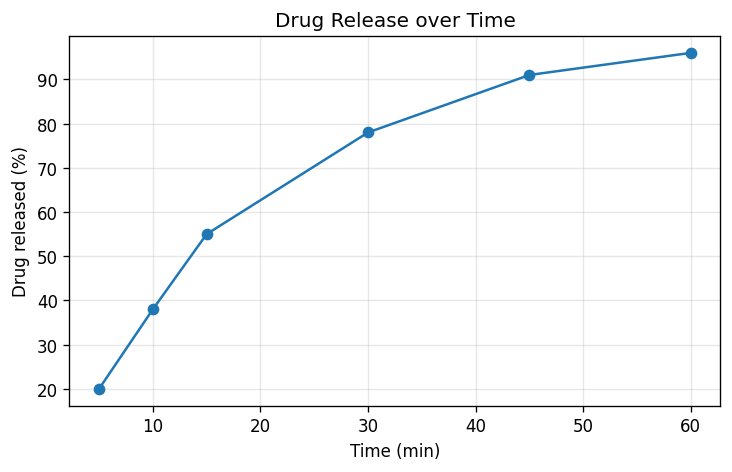

In [5]:
import matplotlib.pyplot as plt

time_min = [5, 10, 15, 30, 45, 60]
release_percent = [20, 38, 55, 78, 91, 96]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(time_min, release_percent, marker="o")
ax.set_title("Drug Release over Time")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Drug released (%)")
ax.grid(True, alpha=0.3)
plt.show()

### Explanation

`plt.subplots()` returns two objects. `fig` represents the complete figure, while `ax` is the region where the line is drawn. The `set_...()` methods belong to the Axes object.

### Interpretation

Time is an ordered variable, so joining measurements with a line is meaningful. The rising simulated release percentage shows the direction of change over time; it does not by itself establish compliance with any official dissolution specification.

<a id="example-12-5"></a>

## 05. Worked Program 12.2 - Line Plot of a Dissolution Trend

### Problem statement

Visualize the change in simulated drug release over time.

### Objective

To create a line plot and interpret the direction and rate of change over ordered time points.

### Pharmacy context

The simulated curve rises rapidly during the earlier sampling period and approaches a plateau later. The graph supports a statement about the observed classroom dataset only; it does not establish a pharmacopoeial pass/fail decision.

### Algorithm

1. Store the time values.
2. Store the release percentages.
3. Create a Figure.
4. Plot release against time with visible markers.
5. Add a title, units and grid.
6. Display the plot.

### Variables and parameters

| Variable / Parameter | Meaning | Unit / Role |
| --- | --- | --- |
| time_min | Sampling time | min |
| release_percent | Simulated released drug | % |
| marker | Shows each measured point | plot parameter |

### Code and executed output

The output appears directly below the code cell.

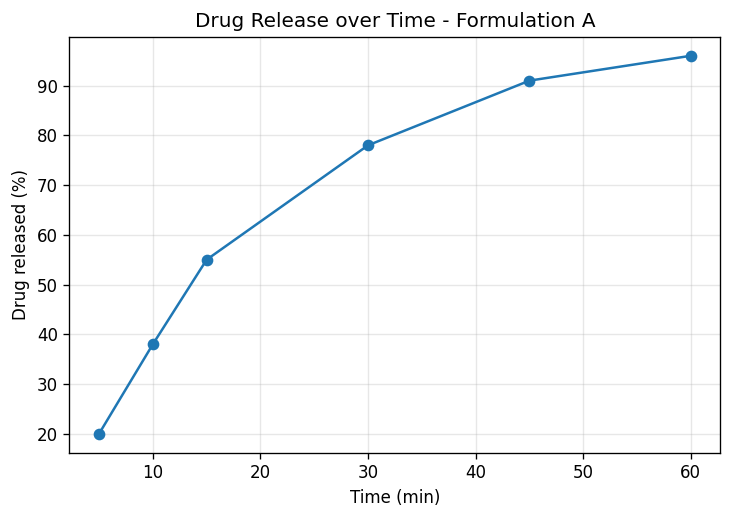

In [6]:
import matplotlib.pyplot as plt

time_min = [5, 10, 15, 30, 45, 60]
release_percent = [20, 38, 55, 78, 91, 96]

plt.figure(figsize=(7, 4.5))
plt.plot(time_min, release_percent, marker="o")
plt.title("Drug Release over Time - Formulation A")
plt.xlabel("Time (min)")
plt.ylabel("Drug released (%)")
plt.grid(True, alpha=0.3)
plt.show()

### Explanation

The x-values are ordered sampling times. The line makes the time trend visible, while the markers show where measurements actually exist.

### Interpretation

The simulated curve rises rapidly during the earlier sampling period and approaches a plateau later. The graph supports a statement about the observed classroom dataset only; it does not establish a pharmacopoeial pass/fail decision.

<a id="example-12-6"></a>

## 06. Worked Program 12.3 - Histogram of Tablet Weights

### Problem statement

Visualize the distribution of simulated tablet weights from a quality-control dataset.

### Objective

To create a histogram and interpret the effect of binning on a continuous pharmaceutical measurement.

### Pharmacy context

In this simulated dataset, weights cluster around approximately 500 mg. A histogram can suggest symmetry, skewness or unusual values, but its appearance depends partly on the selected number and position of bins. A formal quality decision would require the applicable validated specification and test procedure, which are outside this classroom example.

### Algorithm

1. Read the tablet QC dataset.
2. Select the `weight_mg` column.
3. Divide the weight range into eight bins.
4. Count observations in each bin.
5. Label axes and display the histogram.
6. Calculate the mean and sample standard deviation for numerical context.

### Variables and parameters

| Variable / Parameter | Meaning | Unit / Role |
| --- | --- | --- |
| qc | Pandas DataFrame | dataset |
| weight_mg | Individual tablet weight | mg |
| bins | Number of intervals | 8 |
| mean_weight | Average tablet weight | mg |
| sd_weight | Sample standard deviation | mg |

### Code and executed output

The output appears directly below the code cell.

Mean weight = 500.36 mg; sample SD = 6.50 mg


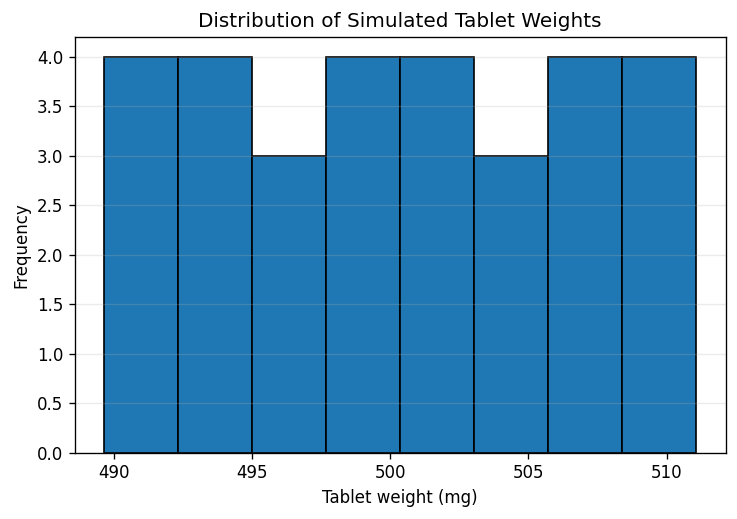

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

qc = pd.read_csv(DATA_DIR / "tablet_qc.csv")
mean_weight = qc["weight_mg"].mean()
sd_weight = qc["weight_mg"].std()

plt.figure(figsize=(7, 4.5))
plt.hist(qc["weight_mg"], bins=8, edgecolor="black")
plt.title("Distribution of Simulated Tablet Weights")
plt.xlabel("Tablet weight (mg)")
plt.ylabel("Frequency")
plt.grid(True, axis="y", alpha=0.25)
plt.show()

print(f"Mean weight = {mean_weight:.2f} mg; sample SD = {sd_weight:.2f} mg")

### Explanation

The histogram counts tablets within weight intervals. The printed mean and SD summarize the same data numerically, while the graph shows how observations are distributed around the centre.

### Interpretation

In this simulated dataset, weights cluster around approximately 500 mg. A histogram can suggest symmetry, skewness or unusual values, but its appearance depends partly on the selected number and position of bins. A formal quality decision would require the applicable validated specification and test procedure, which are outside this classroom example.

<a id="example-12-7"></a>

## 07. Worked Program 12.4 - Tablet Hardness versus Disintegration Time

### Problem statement

Examine whether tablet hardness and disintegration time show an association in the simulated QC dataset.

### Objective

To create a scatter plot and calculate a correlation coefficient as a numerical companion to the visual pattern.

### Pharmacy context

The observed positive association is useful for exploration, but it does not prove that hardness alone caused the disintegration times. Formulation composition, compression conditions and measurement variation could also contribute.

### Algorithm

1. Read the QC dataset.
2. Select hardness as x.
3. Select disintegration time as y.
4. Plot one point per tablet.
5. Calculate the Pearson correlation coefficient using Pandas.
6. Interpret direction and strength cautiously.

### Variables and parameters

| Variable / Parameter | Meaning | Unit / Role |
| --- | --- | --- |
| hardness_n | Tablet hardness | N |
| disintegration_min | Disintegration time | min |
| r | Pearson correlation coefficient | -1 to +1 |

### Code and executed output

The output appears directly below the code cell.

Correlation = 0.62


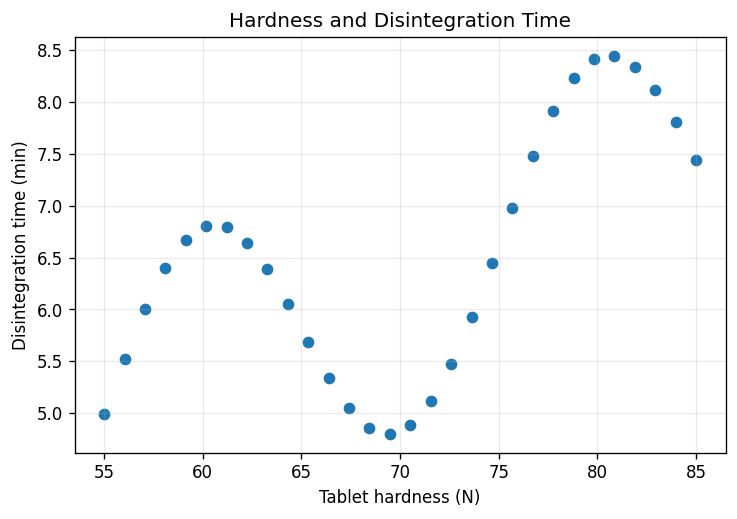

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

qc = pd.read_csv(DATA_DIR / "tablet_qc.csv")
r = qc[["hardness_n", "disintegration_min"]].corr().iloc[0, 1]

plt.figure(figsize=(7, 4.5))
plt.scatter(qc["hardness_n"], qc["disintegration_min"])
plt.title("Hardness and Disintegration Time")
plt.xlabel("Tablet hardness (N)")
plt.ylabel("Disintegration time (min)")
plt.grid(True, alpha=0.25)
plt.show()

print(f"Correlation = {r:.2f}")

### Explanation

Each dot represents one simulated tablet with paired hardness and disintegration measurements. Pearson correlation is approximately 0.62, but the scatter plot shows a curved pattern rather than a simple straight-line cloud. A single correlation coefficient does not capture this shape.

### Interpretation

The recorded association describes this synthetic dataset only. Inspect the plot as well as the coefficient; do not infer causation, a universal linear relationship or a product-quality decision from this example.

<a id="example-12-8"></a>

## 08. Worked Program 12.5 - Comparing Assay Results by Batch

### Problem statement

Compare the centre, spread and potential unusual observations of assay values across three simulated batches.

### Objective

To create a grouped box plot and interpret median, spread and potential outliers without overreacting to a single point.

### Pharmacy context

Batch B has the highest simulated median, while Batch C has the lowest. Any potential outlier must be checked against the raw record, measurement process and study protocol before a decision is made. The graph by itself is not a batch-release decision.

### Algorithm

1. Read the QC dataset.
2. Separate assay values for Batch A, B and C.
3. Create one box for each group.
4. Label the y-axis and title.
5. Display the plot.
6. Calculate the median assay for each batch.

### Variables and parameters

| Variable / Parameter | Meaning | Unit / Role |
| --- | --- | --- |
| groups | Three arrays of assay results | % |
| tick_labels | Names shown below boxes | Batch A/B/C |
| median | Middle value of each group | % |

### Code and executed output

The output appears directly below the code cell.

Batch medians: A = 98.90%, B = 100.61%, C = 98.53%


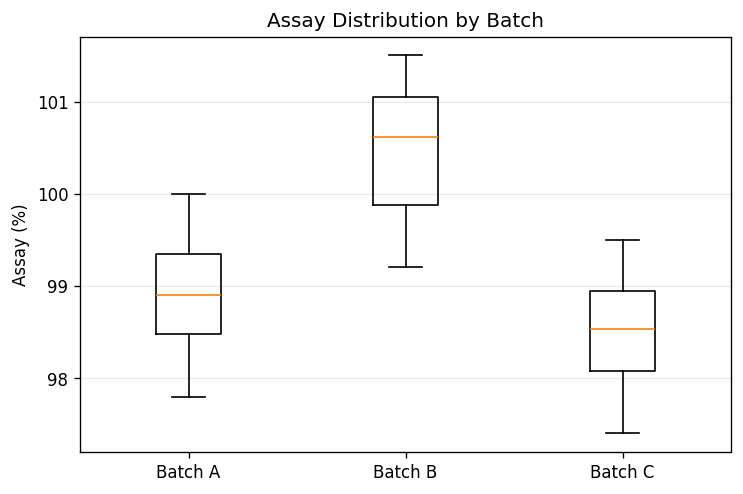

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

qc = pd.read_csv(DATA_DIR / "tablet_qc.csv")
labels = ["A", "B", "C"]
groups = [qc.loc[qc["batch"] == b, "assay_percent"] for b in labels]

plt.figure(figsize=(7, 4.5))
plt.boxplot(groups, tick_labels=["Batch A", "Batch B", "Batch C"])
plt.title("Assay Distribution by Batch")
plt.ylabel("Assay (%)")
plt.grid(True, axis="y", alpha=0.25)
plt.show()

medians = qc.groupby("batch")["assay_percent"].median()
print(
    f"Batch medians: A = {medians['A']:.2f}%, "
    f"B = {medians['B']:.2f}%, C = {medians['C']:.2f}%"
)

### Explanation

The boxes compare centre and spread using the same visual grammar for all three batches. An isolated point may appear when an observation lies beyond the default whisker rule.

### Interpretation

Batch B has the highest simulated median, while Batch C has the lowest. Any potential outlier must be checked against the raw record, measurement process and study protocol before a decision is made. The graph by itself is not a batch-release decision.

<a id="example-12-9"></a>

## 09. Worked Program 12.6 - Adding Labels, Legend and Grid to Two Curves

### Problem statement

Plot simulated oral and IV concentration-time profiles together and make the figure self-explanatory.

### Objective

To practise labels with units, a legend, markers and grid lines on a multiple-line pharmaceutical figure.

### Pharmacy context

The oral profile rises from zero to a peak and then declines, whereas the IV profile begins at a high concentration and declines from the first time point. This shape difference reflects the simulated route-specific data and is explored quantitatively later in the chapter.

### Algorithm

1. Read the PK dataset.
2. Plot oral concentration against time.
3. Plot IV concentration on the same Axes.
4. Supply a different label for each series.
5. Add title, x-label, y-label and legend.
6. Add a light grid and display the figure.

### Variables and parameters

| Variable / Parameter | Meaning | Unit / Role |
| --- | --- | --- |
| time_h | Time after dose | h |
| oral_conc_ug_ml | Oral concentration | µg/mL |
| iv_conc_ug_ml | IV concentration | µg/mL |
| label | Text used by legend | series identifier |

### Code and executed output

The output appears directly below the code cell.

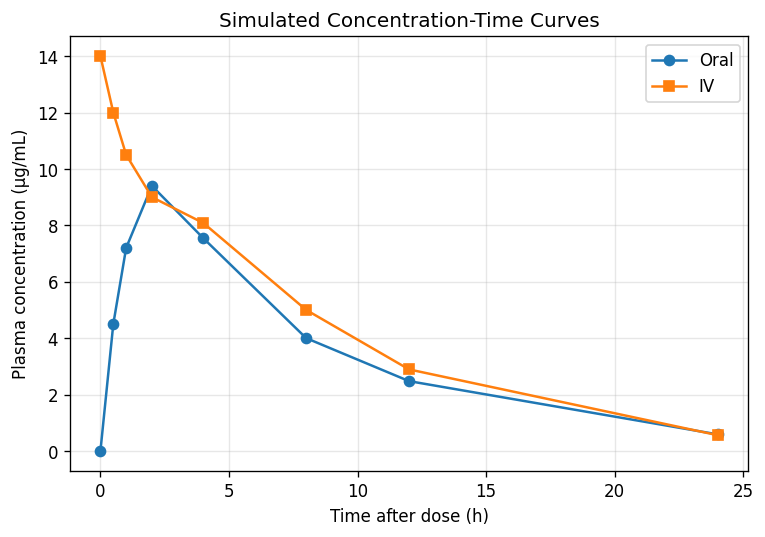

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

pk = pd.read_csv(DATA_DIR / "pk_oral_iv.csv")

plt.figure(figsize=(7.3, 4.7))
plt.plot(pk["time_h"], pk["oral_conc_ug_ml"], marker="o", label="Oral")
plt.plot(pk["time_h"], pk["iv_conc_ug_ml"], marker="s", label="IV")
plt.title("Simulated Concentration-Time Curves")
plt.xlabel("Time after dose (h)")
plt.ylabel("Plasma concentration (µg/mL)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Explanation

The legend uses the `label` values supplied to each plotted line. Axis labels state both variable and unit, so the graph can be interpreted without reading the Python code.

### Interpretation

The oral profile rises from zero to a peak and then declines, whereas the IV profile begins at a high concentration and declines from the first time point. This shape difference reflects the simulated route-specific data and is explored quantitatively later in the chapter.

<a id="example-12-10"></a>

## 10. Worked Program 12.7 - Two Axes in One Figure and Exporting the Figure

### Problem statement

Create a Figure containing two Axes and save it as a sharp PNG file.

### Objective

To use `plt.subplots()`, address each Axes separately, improve spacing with `tight_layout()` and export a publication-ready raster image.

### Pharmacy context

Use multiple panels only when the relationship between panels helps the reader. A saved figure should retain readable labels at its final report size. For journal or print workflows, vector formats such as PDF or SVG can also be useful.

### Algorithm

1. Read the PK and QC datasets.
2. Create one Figure with two Axes in one row.
3. Draw a line plot in the first Axes.
4. Draw a histogram in the second Axes.
5. Add labels and titles.
6. Apply `tight_layout()`.
7. Save at 300 dpi before displaying.

### Variables and parameters

| Variable / Parameter | Meaning | Unit / Role |
| --- | --- | --- |
| fig | Complete figure | two-panel canvas |
| axes[0] | First Axes | line plot |
| axes[1] | Second Axes | histogram |
| dpi | Dots per inch for raster export | 300 |

### Code and executed output

The output appears directly below the code cell.

File created: chapter12_two_panel.png (300 dpi).


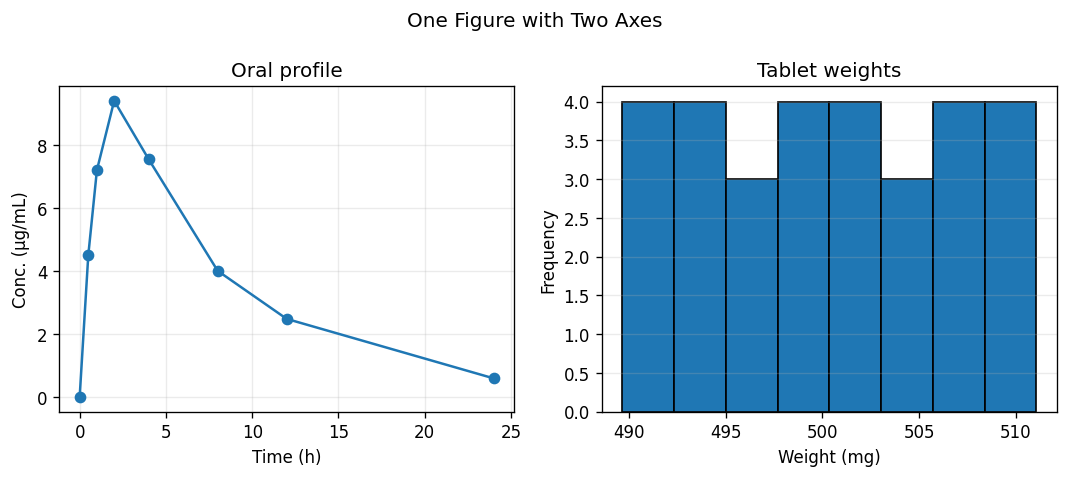

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

pk = pd.read_csv(DATA_DIR / "pk_oral_iv.csv")
qc = pd.read_csv(DATA_DIR / "tablet_qc.csv")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].plot(pk["time_h"], pk["oral_conc_ug_ml"], marker="o")
axes[0].set_title("Oral profile")
axes[0].set_xlabel("Time (h)")
axes[0].set_ylabel("Conc. (µg/mL)")
axes[0].grid(True, alpha=0.25)

axes[1].hist(qc["weight_mg"], bins=8, edgecolor="black")
axes[1].set_title("Tablet weights")
axes[1].set_xlabel("Weight (mg)")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, axis="y", alpha=0.25)

fig.suptitle("One Figure with Two Axes")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "chapter12_two_panel.png", dpi=300, bbox_inches="tight")
print("File created: chapter12_two_panel.png (300 dpi).")
plt.show()

### Explanation

`axes[0]` and `axes[1]` are independent plotting regions. `fig.savefig()` saves the full canvas including both panels. `bbox_inches="tight"` reduces unnecessary outer whitespace.

### Interpretation

Use multiple panels only when the relationship between panels helps the reader. A saved figure should retain readable labels at its final report size. For journal or print workflows, vector formats such as PDF or SVG can also be useful.

<a id="example-12-11"></a>

## 11. Worked Program 12.8 - Oral and IV Profiles with Cmax, Tmax and Sampled AUC

### Problem statement

Compare simulated oral and IV concentration-time profiles and calculate Cmax, Tmax and sampled AUC for interpretation.

### Objective

To combine Matplotlib visualization with NumPy calculations and explain the limits of each parameter.

### Pharmacy context

The simulated oral profile peaks at 2 h and then declines. The IV profile begins higher and decreases from time zero. AUC values here describe the sampled classroom interval and are not an extrapolated AUC to infinity. The semi-log view helps inspect whether the later points approximate a straight-line decline.

### Algorithm

1. Read the PK CSV file.
2. Find the maximum oral concentration (`Cmax`).
3. Find the time corresponding to the maximum (`Tmax`).
4. Calculate sampled AUC with the trapezoidal rule for both routes.
5. Create a linear-scale plot.
6. Create a semi-logarithmic y-axis plot.
7. Print the parameters and interpret them as classroom summaries.

### Variables and parameters

| Variable / Parameter | Meaning | Unit / Role |
| --- | --- | --- |
| Cmax | Maximum observed oral concentration | µg/mL |
| Tmax | Time of observed Cmax | h |
| AUC_0-24 | Area under sampled concentration-time curve | µg·h/mL |
| np.trapezoid | Numerical trapezoidal integration | function |
| semilogy | Logarithmic y-axis line plot | plot method |

### Code and executed output

The output appears directly below the code cell.

Oral Cmax = 9.40 µg/mL
Oral Tmax = 2.00 h
Oral AUC0-24 = 83.70 µg·h/mL
IV AUC0-24 = 101.60 µg·h/mL


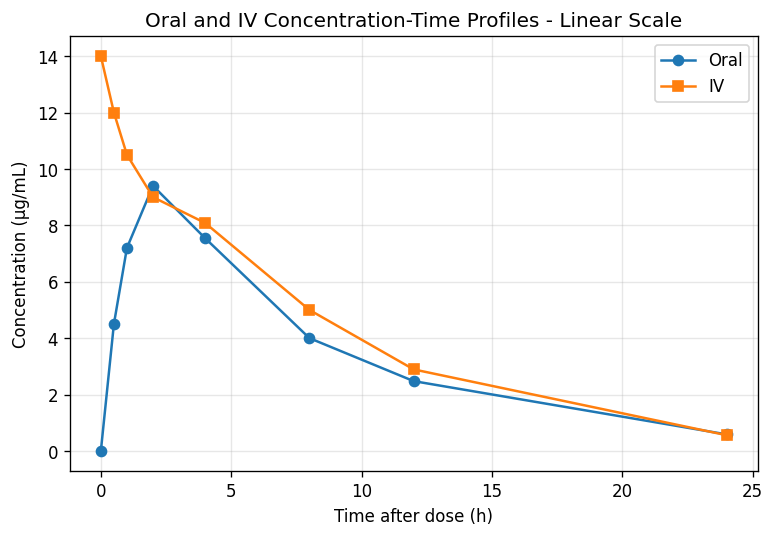

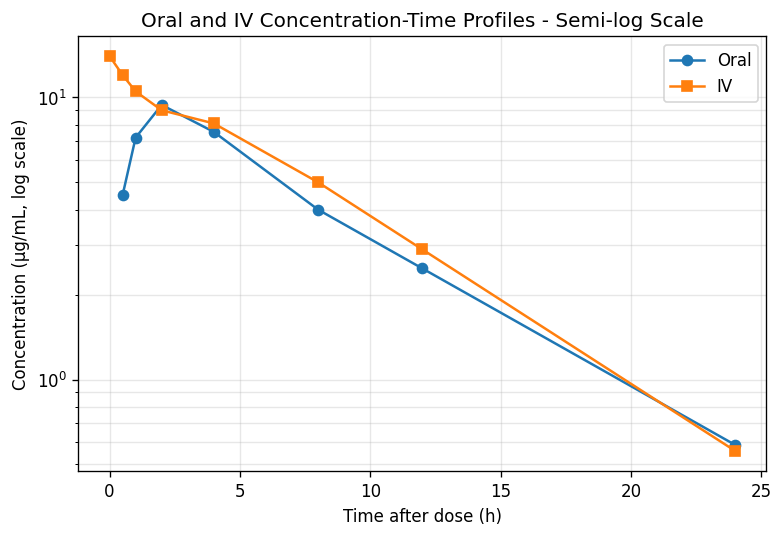

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pk = pd.read_csv(DATA_DIR / "pk_oral_iv.csv")
time = pk["time_h"].to_numpy()
oral = pk["oral_conc_ug_ml"].to_numpy()
iv = pk["iv_conc_ug_ml"].to_numpy()

cmax = oral.max()
tmax = time[oral.argmax()]
auc_oral = np.trapezoid(oral, time)
auc_iv = np.trapezoid(iv, time)

print(f"Oral Cmax = {cmax:.2f} µg/mL")
print(f"Oral Tmax = {tmax:.2f} h")
print(f"Oral AUC0-24 = {auc_oral:.2f} µg·h/mL")
print(f"IV AUC0-24 = {auc_iv:.2f} µg·h/mL")

plt.figure(figsize=(7.4, 4.7))
plt.plot(time, oral, marker="o", label="Oral")
plt.plot(time, iv, marker="s", label="IV")
plt.xlabel("Time after dose (h)")
plt.ylabel("Concentration (µg/mL)")
plt.title("Oral and IV Concentration-Time Profiles - Linear Scale")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7.4, 4.7))
plt.semilogy(time[oral > 0], oral[oral > 0], marker="o", label="Oral")
plt.semilogy(time, iv, marker="s", label="IV")
plt.xlabel("Time after dose (h)")
plt.ylabel("Concentration (µg/mL, log scale)")
plt.title("Oral and IV Concentration-Time Profiles - Semi-log Scale")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

### Explanation

`Cmax` is the largest observed concentration; `Tmax` is the sampling time where that observed maximum occurs. The trapezoidal AUC summarizes exposure over the sampled 0-24 h window. `semilogy` places concentration on a logarithmic y-axis and is useful only for positive values.

### Interpretation

The simulated oral profile peaks at 2 h and then declines. The IV profile begins higher and decreases from time zero. AUC values here describe the sampled classroom interval and are not an extrapolated AUC to infinity. The semi-log view helps inspect whether the later points approximate a straight-line decline.

<a id="example-12-12"></a>

## 12. 12.16 Terminal slope, half-life and the partial oral/IV AUC ratio

### Problem statement

Fit a line to the log of late simulated concentrations, calculate illustrative half-lives and compare the sampled oral and IV AUCs under an equal-dose assumption.

### Objective

Distinguish fitted terminal summaries and a partial AUC ratio from a validated bioavailability assessment.

### Pharmacy context

All plots use simulated data. ADR reporting summaries are not incidence or risk estimates; sampled PK summaries are not dosing recommendations; dissolution means and SD bars do not establish pharmacopoeial compliance.

### Algorithm

1. Import `numpy`.
2. Import `pandas`.
3. Store `pd.read_csv(DATA_DIR / 'pk_oral_iv.csv')` in `pk`.
4. Store `pk['time_h'].to_numpy()` in `time`.
5. Store `pk['oral_conc_ug_ml'].to_numpy()` in `oral`.
6. Complete the remaining calculations and display the results with their labels.

### Important notes

Terminology correction: this is a sampled oral/IV partial AUC ratio under an equal-dose assumption. It is not a definitive bioavailability estimate. A proper comparison with IV concerns absolute bioavailability, not relative bioavailability between non-IV formulations; total exposure and appropriate study assumptions are required.

### Code and executed output

The output appears directly below the code cell.

In [13]:
import numpy as np
import pandas as pd

pk = pd.read_csv(DATA_DIR / "pk_oral_iv.csv")
time = pk["time_h"].to_numpy()
oral = pk["oral_conc_ug_ml"].to_numpy()
iv = pk["iv_conc_ug_ml"].to_numpy()

auc_oral = np.trapezoid(oral, time)
auc_iv = np.trapezoid(iv, time)

terminal = pk[pk["time_h"] >= 8]
slope_o, _ = np.polyfit(
    terminal["time_h"], np.log(terminal["oral_conc_ug_ml"]), 1
)
slope_iv, _ = np.polyfit(
    terminal["time_h"], np.log(terminal["iv_conc_ug_ml"]), 1
)

lambda_z_oral = -slope_o
lambda_z_iv = -slope_iv
half_life_oral = np.log(2) / lambda_z_oral
half_life_iv = np.log(2) / lambda_z_iv

# Equal classroom doses are assumed only for this teaching example.
partial_auc_ratio_percent = (auc_oral / auc_iv) * 100

print(f"Illustrative oral terminal slope constant λz = {lambda_z_oral:.3f} h⁻¹")
print(f"Illustrative oral half-life = {half_life_oral:.2f} h")
print(f"Illustrative IV terminal slope constant λz = {lambda_z_iv:.3f} h⁻¹")
print(f"Illustrative IV half-life = {half_life_iv:.2f} h")
print(
    "Illustrative oral/IV partial AUC0-24 ratio for equal doses = "
    f"{partial_auc_ratio_percent:.1f}%"
)

Illustrative oral terminal slope constant λz = 0.120 h⁻¹
Illustrative oral half-life = 5.78 h
Illustrative IV terminal slope constant λz = 0.137 h⁻¹
Illustrative IV half-life = 5.06 h
Illustrative oral/IV partial AUC0-24 ratio for equal doses = 82.4%


### Explanation

The negative slope of log concentration gives an illustrative terminal rate constant. ln(2) divided by this constant gives a fitted half-life. The AUC ratio uses only the observed 0–24 h window.

### Interpretation

The ratio compares oral and IV sampled exposure over 0–24 hours only. It is not total exposure, a clinical estimate of bioavailability or a recommendation for dose selection.

<a id="example-12-13"></a>

## 13. Worked Program 12.9 - Bar Chart of Simulated ADR Reporting Rates

### Problem statement

Compare simulated ADR reporting summaries fairly across categories with different denominator sizes.

### Objective

To calculate a denominator-based classroom reporting rate and display it using a bar chart while maintaining cautious pharmacovigilance interpretation.

### Pharmacy context

Warfarin has the highest simulated reporting summary in this classroom dataset. That observation should be described as a reporting pattern only. It is not proof of incidence, relative risk or causality because the synthetic denominator and reporting process do not provide the information required for those claims.

### Algorithm

1. Read the ADR reporting dataset.
2. Calculate `adr_reports / monitored_records * 1000`.
3. Use drug names as x-axis categories.
4. Use the calculated rate as bar height.
5. Start the bar-chart y-axis at zero.
6. Add labels and display the plot.

### Variables and parameters

| Variable / Parameter | Meaning | Unit / Role |
| --- | --- | --- |
| drug | Drug category | categorical |
| monitored_records | Synthetic denominator | records |
| adr_reports | Number of synthetic reports | count |
| adr_reports_per_1000 | Calculated reporting summary | reports/1000 records |

### Important notes

The denominator is checked before division. These are reports per 1,000 monitored records in a simulated dataset, not incidence, relative risk or a drug-safety ranking.

### Code and executed output

The output appears directly below the code cell.

Calculated rates (reports per 1000 monitored records): Amoxicillin 5.00; Aspirin 6.00; Metformin 4.23; Warfarin 11.11; Atorvastatin 3.60; Ibuprofen 5.36


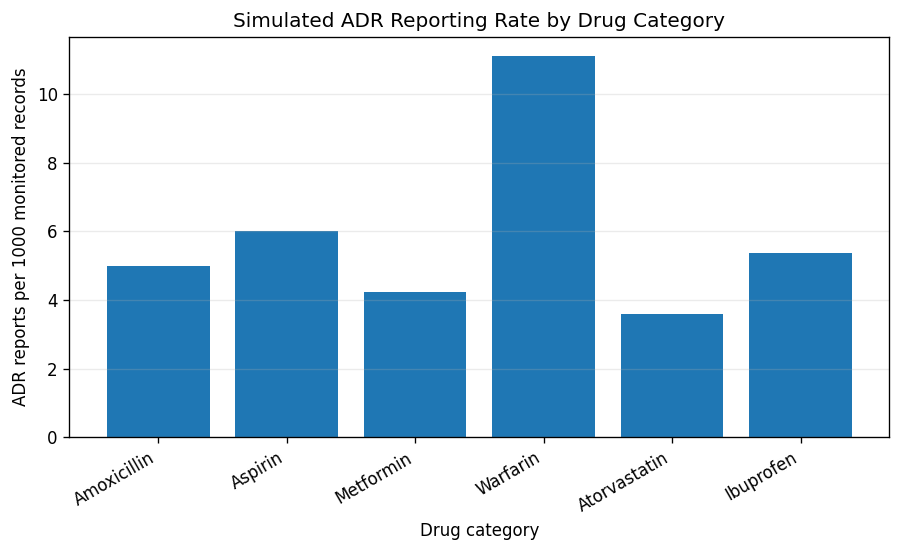

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

adr = pd.read_csv(DATA_DIR / "adr_reporting.csv")
assert adr["monitored_records"].gt(0).all(), "Every denominator must be positive."
assert adr["adr_reports"].ge(0).all(), "Report counts cannot be negative."
adr["adr_reports_per_1000"] = (
    adr["adr_reports"] / adr["monitored_records"] * 1000
)

plt.figure(figsize=(7.6, 4.7))
plt.bar(adr["drug"], adr["adr_reports_per_1000"])
plt.title("Simulated ADR Reporting Rate by Drug Category")
plt.xlabel("Drug category")
plt.ylabel("ADR reports per 1000 monitored records")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.25)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

rate_text = "; ".join(
    f"{row.drug} {row.adr_reports_per_1000:.2f}"
    for row in adr.itertuples()
)
print("Calculated rates (reports per 1000 monitored records): " + rate_text)

### Explanation

The denominator standardizes the category summaries so that categories with different numbers of monitored records can be compared on the same basis. A bar chart is appropriate because the x-axis contains separate categories.

### Interpretation

Warfarin has the highest simulated reporting summary in this classroom dataset. That observation should be described as a reporting pattern only. It is not proof of incidence, relative risk or causality because the synthetic denominator and reporting process do not provide the information required for those claims.

<a id="example-12-14"></a>

## 14. Worked Program 12.10 - Comparing Three Dissolution Profiles with SD Error Bars

### Problem statement

Compare the time-dependent release of three simulated formulations while preserving information about between-vessel variability.

### Objective

To group replicate dissolution observations, calculate mean and SD, create an error-bar line plot and interpret an illustrative classroom reference line responsibly.

### Pharmacy context

Formulation A has the highest simulated mean release at 45 min, followed by B and C. The dashed 80% line is explicitly labelled as an illustrative classroom reference and must not be treated as an official monograph criterion. A real decision would require the applicable product monograph, stage rules and validated method.

### Algorithm

1. Read the dissolution CSV file.
2. Group by formulation and time.
3. Calculate mean and sample SD of release percent.
4. Plot each formulation with `errorbar()`.
5. Add SD error bars and a legend.
6. Add an illustrative classroom horizontal reference at 80%.
7. Label axes and display the figure.

### Variables and parameters

| Variable / Parameter | Meaning | Unit / Role |
| --- | --- | --- |
| release_percent | Individual simulated vessel result | % |
| mean | Mean of six vessels at a time point | % |
| std | Sample standard deviation | % |
| yerr | Vertical error-bar length | SD |
| Q line | Illustrative classroom reference | 80%, not official specification |

### Important notes

The Q = 80% reference is an illustrative classroom line only. Mean curves and SD error bars cannot replace stage-specific, unit-level dissolution acceptance rules.

### Code and executed output

The output appears directly below the code cell.

At 45 min, mean release is approximately: Formulation A 90.0%; Formulation B 83.3%; Formulation C 72.6%


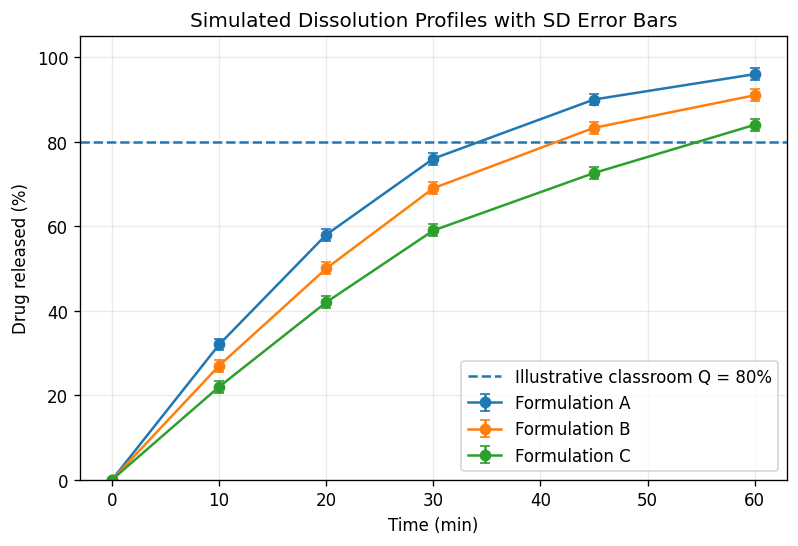

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

diss = pd.read_csv(DATA_DIR / "dissolution.csv")
summary = (
    diss.groupby(["formulation", "time_min"])["release_percent"]
        .agg(["mean", "std"])
        .reset_index()
)

fig, ax = plt.subplots(figsize=(7.6, 4.8))
for formulation in summary["formulation"].unique():
    s = summary[summary["formulation"] == formulation]
    ax.errorbar(
        s["time_min"], s["mean"], yerr=s["std"],
        marker="o", capsize=3, label=formulation
    )

ax.axhline(80, linestyle="--", label="Illustrative classroom Q = 80%")
ax.set_title("Simulated Dissolution Profiles with SD Error Bars")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Drug released (%)")
ax.set_ylim(0, 105)
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

mean_45 = summary.loc[summary["time_min"] == 45].set_index("formulation")["mean"]
print(
    "At 45 min, mean release is approximately: "
    f"Formulation A {mean_45['Formulation A']:.1f}%; "
    f"Formulation B {mean_45['Formulation B']:.1f}%; "
    f"Formulation C {mean_45['Formulation C']:.1f}%"
)

### Explanation

Each line shows the mean release over time for one formulation. Vertical error bars represent sample SD across six simulated vessels, so wider bars indicate greater between-vessel variability at that time point.

### Interpretation

Formulation A has the highest simulated mean release at 45 min, followed by B and C. The dashed 80% line is explicitly labelled as an illustrative classroom reference and must not be treated as an official monograph criterion. A real decision would require the applicable product monograph, stage rules and validated method.

<a id="example-12-15"></a>

## 15. Worked Program 12.11 - Creating and Saving an ADR Summary Figure

### Problem statement

Produce a reproducible figure from a pharmaceutical-style dataset and export it for a report.

### Objective

To integrate Pandas calculation, plot selection, scientific labelling and file export in one Jupyter workflow.

### Pharmacy context

The figure is suitable for a classroom report because it names the numerator-derived summary, states the denominator basis and uses a zero bar-chart baseline. The interpretation must still avoid claims of incidence, risk or causality.

### Algorithm

1. Read the ADR CSV file.
2. Verify the required columns.
3. Calculate reports per 1000 monitored records.
4. Sort by the calculated rate.
5. Create a bar chart because drug names are categories.
6. Use a zero baseline and clear units.
7. Save as PNG at 300 dpi before showing.
8. Write a cautious interpretation.

### Variables and parameters

| Variable / Parameter | Meaning | Unit / Role |
| --- | --- | --- |
| adr | Pandas DataFrame | source data |
| rate | Reports standardized per 1000 monitored records | summary |
| sort_values | Orders categories by rate | readability |
| dpi | Raster export resolution | 300 |

### Important notes

The denominator is checked before division. These are reports per 1,000 monitored records in a simulated dataset, not incidence, relative risk or a drug-safety ranking.

### Code and executed output

The output appears directly below the code cell.

Figure file created: adr_summary_300dpi.png


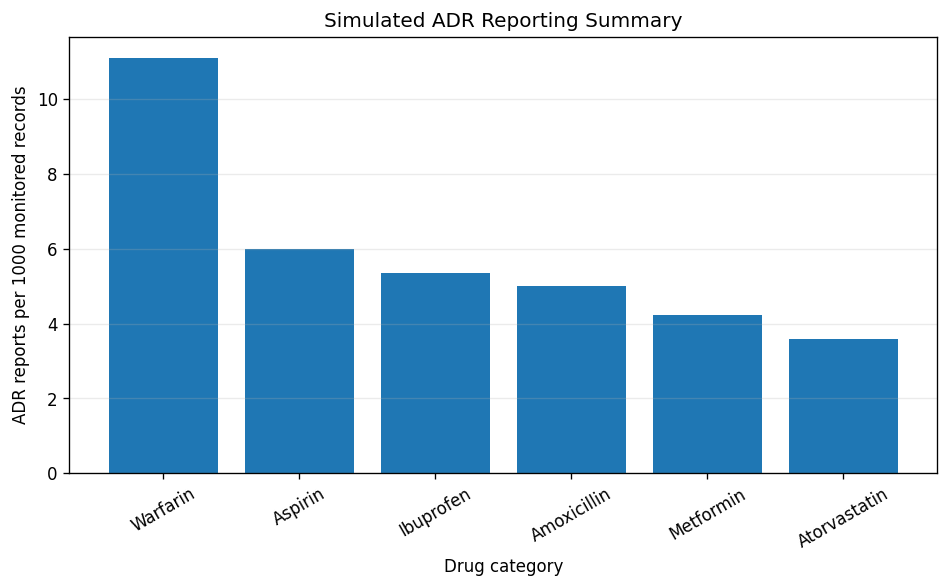

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

adr = pd.read_csv(DATA_DIR / "adr_reporting.csv")
assert adr["monitored_records"].gt(0).all(), "Every denominator must be positive."
assert adr["adr_reports"].ge(0).all(), "Report counts cannot be negative."
adr["rate"] = adr["adr_reports"] / adr["monitored_records"] * 1000
plot_df = adr.sort_values("rate", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_df["drug"], plot_df["rate"])
ax.set_title("Simulated ADR Reporting Summary")
ax.set_xlabel("Drug category")
ax.set_ylabel("ADR reports per 1000 monitored records")
ax.set_ylim(bottom=0)
ax.tick_params(axis="x", rotation=30)
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "adr_summary_300dpi.png", dpi=300, bbox_inches="tight")
print("Figure file created: adr_summary_300dpi.png")
plt.show()

### Explanation

The code records every step required to reproduce the figure. Sorting changes display order only; it does not change the underlying rates. Saving before `show()` is a reliable habit for notebook and script workflows.

### Interpretation

The figure is suitable for a classroom report because it names the numerator-derived summary, states the denominator basis and uses a zero bar-chart baseline. The interpretation must still avoid claims of incidence, risk or causality.

## Review and practice

- Change one simulated input and predict the effect before rerunning the relevant cell.
- State the unit and meaning of each reported result.
- Explain one input condition or limitation that matters for the example.
- Restart the kernel and run all cells to check that the notebook is reproducible.

## Source and validation

Adapted from **Chapter_12_Pharmaceutical_Data_Visualization_with_Matplotlib_BPharm_Corrected_Executable.docx**. Worked programs and the complete code demonstrations are retained in chapter order. Installation commands are optional instructions; intentionally broken debugging examples are shown as corrected solutions. Notebook-specific changes are recorded in `Notebook_Guide_and_Validation.md`.